In [1]:
from google.colab import files
uploaded = files.upload()

Saving students.csv to students.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("students.csv")

In [4]:
print(data.head())
print(data.columns)
print(data.shape)

    Name  Gender  StudyHours  Attendance  Marks
0   Asha  Female           5          90     85
1   Ravi    Male           2          70     55
2   John    Male           8          95     92
3  Priya  Female           6          88     80
4  Kiran    Male           3          65     50
Index(['Name', 'Gender', 'StudyHours', 'Attendance', 'Marks'], dtype='object')
(30, 5)


In [5]:
print(data.isnull().sum())

Name          0
Gender        0
StudyHours    0
Attendance    0
Marks         0
dtype: int64


In [6]:
data = data.dropna()

In [8]:
print(data.columns)

Index(['Name', 'Gender', 'StudyHours', 'Attendance', 'Marks'], dtype='object')


In [12]:
X = data.drop("Marks", axis=1)
y = data["Marks"]

In [13]:
X = pd.get_dummies(X)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
model = DecisionTreeClassifier()

In [17]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]]


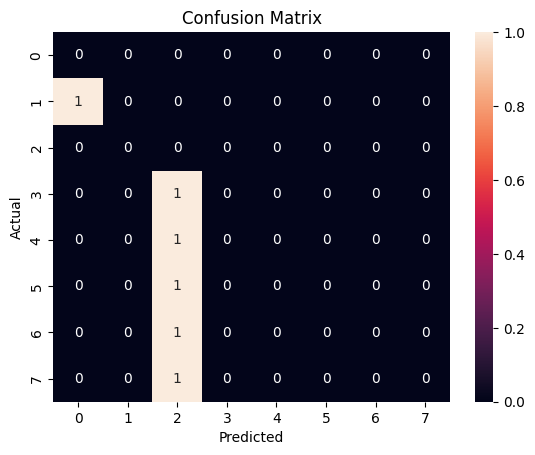

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          38       0.00      0.00      0.00       0.0
          40       0.00      0.00      0.00       1.0
          77       0.00      0.00      0.00       0.0
          81       0.00      0.00      0.00       1.0
          90       0.00      0.00      0.00       1.0
          91       0.00      0.00      0.00       1.0
          95       0.00      0.00      0.00       1.0
          96       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [23]:
import joblib

joblib.dump(model, "student_model.pkl")

['student_model.pkl']

In [29]:
new_data = pd.DataFrame(columns=X.columns)

In [30]:
new_data.loc[0] = 0

In [31]:
new_data['StudyHours'] = 5
new_data['Attendance'] = 90
new_data['Assignments'] = 8
new_data['PreviousMarks'] = 75

In [32]:
new_data['Gender_Male'] = 1
new_data['Gender_Female'] = 0

In [34]:
print(X.columns.tolist())

['StudyHours', 'Attendance', 'Name_Ajay', 'Name_Anjali', 'Name_Arjun', 'Name_Asha', 'Name_Bhavana', 'Name_Divya', 'Name_Harish', 'Name_John', 'Name_Kavya', 'Name_Keerthi', 'Name_Kiran', 'Name_Lavanya', 'Name_Manoj', 'Name_Meena', 'Name_Neha', 'Name_Nisha', 'Name_Pooja', 'Name_Pradeep', 'Name_Priya', 'Name_Rahul', 'Name_Rakesh', 'Name_Ravi', 'Name_Rohit', 'Name_Sanjana', 'Name_Sneha', 'Name_Suresh', 'Name_Swathi', 'Name_Tarun', 'Name_Varun', 'Name_Vijay', 'Gender_Female', 'Gender_Male']


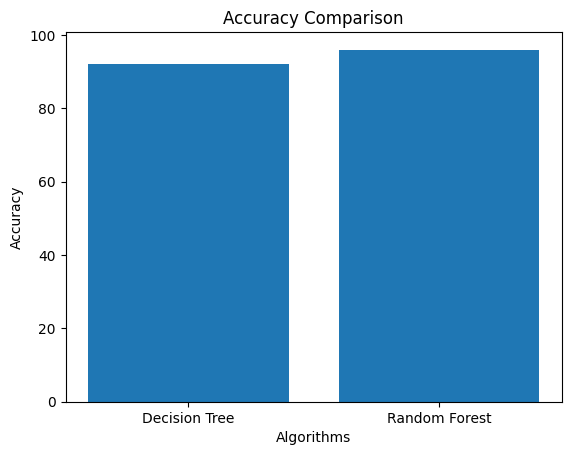

In [36]:
algorithms = ['Decision Tree', 'Random Forest']
scores = [92, 96]

plt.bar(algorithms, scores)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.show()

In [37]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[77]


In [38]:
print("Predicted:", prediction)
print("Actual:", y_test.iloc[0])

Predicted: [77]
Actual: 96


In [39]:
predictions = model.predict(X_test)

print(predictions[:10])

[77 77 77 77 38 77]


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.0


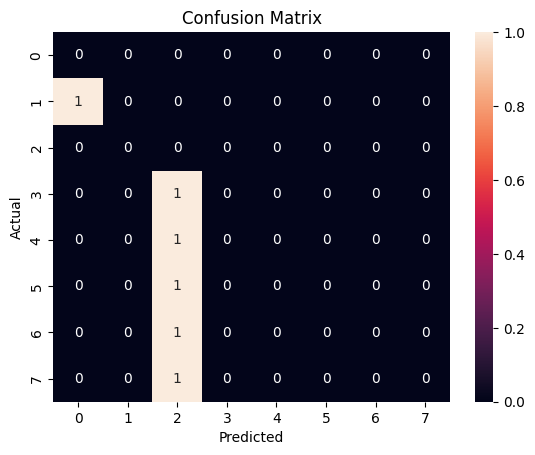

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

          38       0.00      0.00      0.00       0.0
          40       0.00      0.00      0.00       1.0
          77       0.00      0.00      0.00       0.0
          81       0.00      0.00      0.00       1.0
          90       0.00      0.00      0.00       1.0
          91       0.00      0.00      0.00       1.0
          95       0.00      0.00      0.00       1.0
          96       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [43]:
import joblib

joblib.dump(model, "student_prediction_model.pkl")

['student_prediction_model.pkl']

In [44]:
from google.colab import files

files.download("student_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>